In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/yolov11

Mounted at /content/gdrive
/content/gdrive/.shortcut-targets-by-id/1N1e6L9Tga2bF3c9mKY8K1qjRhbLw7xHn/yolov11


In [2]:
import os

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/surgical_instruments/images/train")
count_images("datasets/surgical_instruments/images/valid")

Total images: 2855
Total images: 841


In [3]:
def count_labels(labels_dir, exts={".txt"}):
    labels_count = 0
    for filename in os.listdir(labels_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            labels_count += 1
    print(f"Total labels: {labels_count}")

count_labels("datasets/surgical_instruments/labels/train")
count_labels("datasets/surgical_instruments/labels/valid")

Total labels: 2855
Total labels: 841


In [4]:
%%writefile datasets/sis_final.yaml
train: ../surgical_instruments/images/train
val: ../surgical_instruments/images/valid
test: ../surgical_instruments/images/test

nc: 7 # Number of classes + bg
names: ['bg', 'Grasper', 'Harmonic_Ace', 'Myoma_Screw', 'Needle_Holder', 'Suction', 'Trocar'] # Classes names

Overwriting datasets/sis_final.yaml


In [5]:
with open("datasets/sis_final.yaml", 'r') as f:
    print(f.read())

train: ../surgical_instruments/images/train
val: ../surgical_instruments/images/valid
test: ../surgical_instruments/images/test

nc: 7 # Number of classes + bg
names: ['bg', 'Grasper', 'Harmonic_Ace', 'Myoma_Screw', 'Needle_Holder', 'Suction', 'Trocar'] # Classes names



In [6]:
!uv pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.7/112.6 GB disk)


In [7]:
from ultralytics import YOLO

In [ ]:
# Load a model
model = YOLO("yolo26m-seg.yaml")  # build a new model from scratch
model = YOLO("yolo26m-seg.pt")  # load a pretrained model (recommended for training)

# Use the model
model.train(data="datasets/sis_final.yaml", epochs=50, imgsz=640, patience=0, batch=16, cache=True)  # train the model

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/sis_final.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=0, perspective=0.0, plots=True, po

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ba1bcbeede0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004

In [ ]:
model = YOLO("runs/segment/train2/weights/best.pt")
model.val()

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO26m-seg summary (fused): 149 layers, 23,512,865 parameters, 0 gradients, 121.2 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.4 ms, read: 26.6±14.2 MB/s, size: 119.0 KB)
val: Scanning /content/gdrive/.shortcut-targets-by-id/1iUbVVIQQHoSFhEFdLy2aP6CuV0yLoXMU/surgical_instruments/labels/valid.cache... 841 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 841/841 207.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 53/53 1.5it/s 34.5s
                   all        841       1215      0.889       0.85      0.917      0.847      0.891      0.854      0.925      0.801
               Grasper        165        200      0.793      0.905      0.908      0.838      0.805       0.92      0.932      0.779
          Harmonic_Ace        200        200       0.92      0.925      0.969      0.925      0.9

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ba1bcb4a600>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004

In [49]:
!ls runs/segment/train2/

args.yaml			 MaskP_curve.png      train_batch7161.jpg
BoxF1_curve.png			 MaskPR_curve.png     train_batch7162.jpg
BoxP_curve.png			 MaskR_curve.png      val_batch0_labels.jpg
BoxPR_curve.png			 results.csv	      val_batch0_pred.jpg
BoxR_curve.png			 results.png	      val_batch1_labels.jpg
confusion_matrix_normalized.png  train_batch0.jpg     val_batch1_pred.jpg
confusion_matrix.png		 train_batch1.jpg     val_batch2_labels.jpg
labels.jpg			 train_batch2.jpg     val_batch2_pred.jpg
MaskF1_curve.png		 train_batch7160.jpg  weights


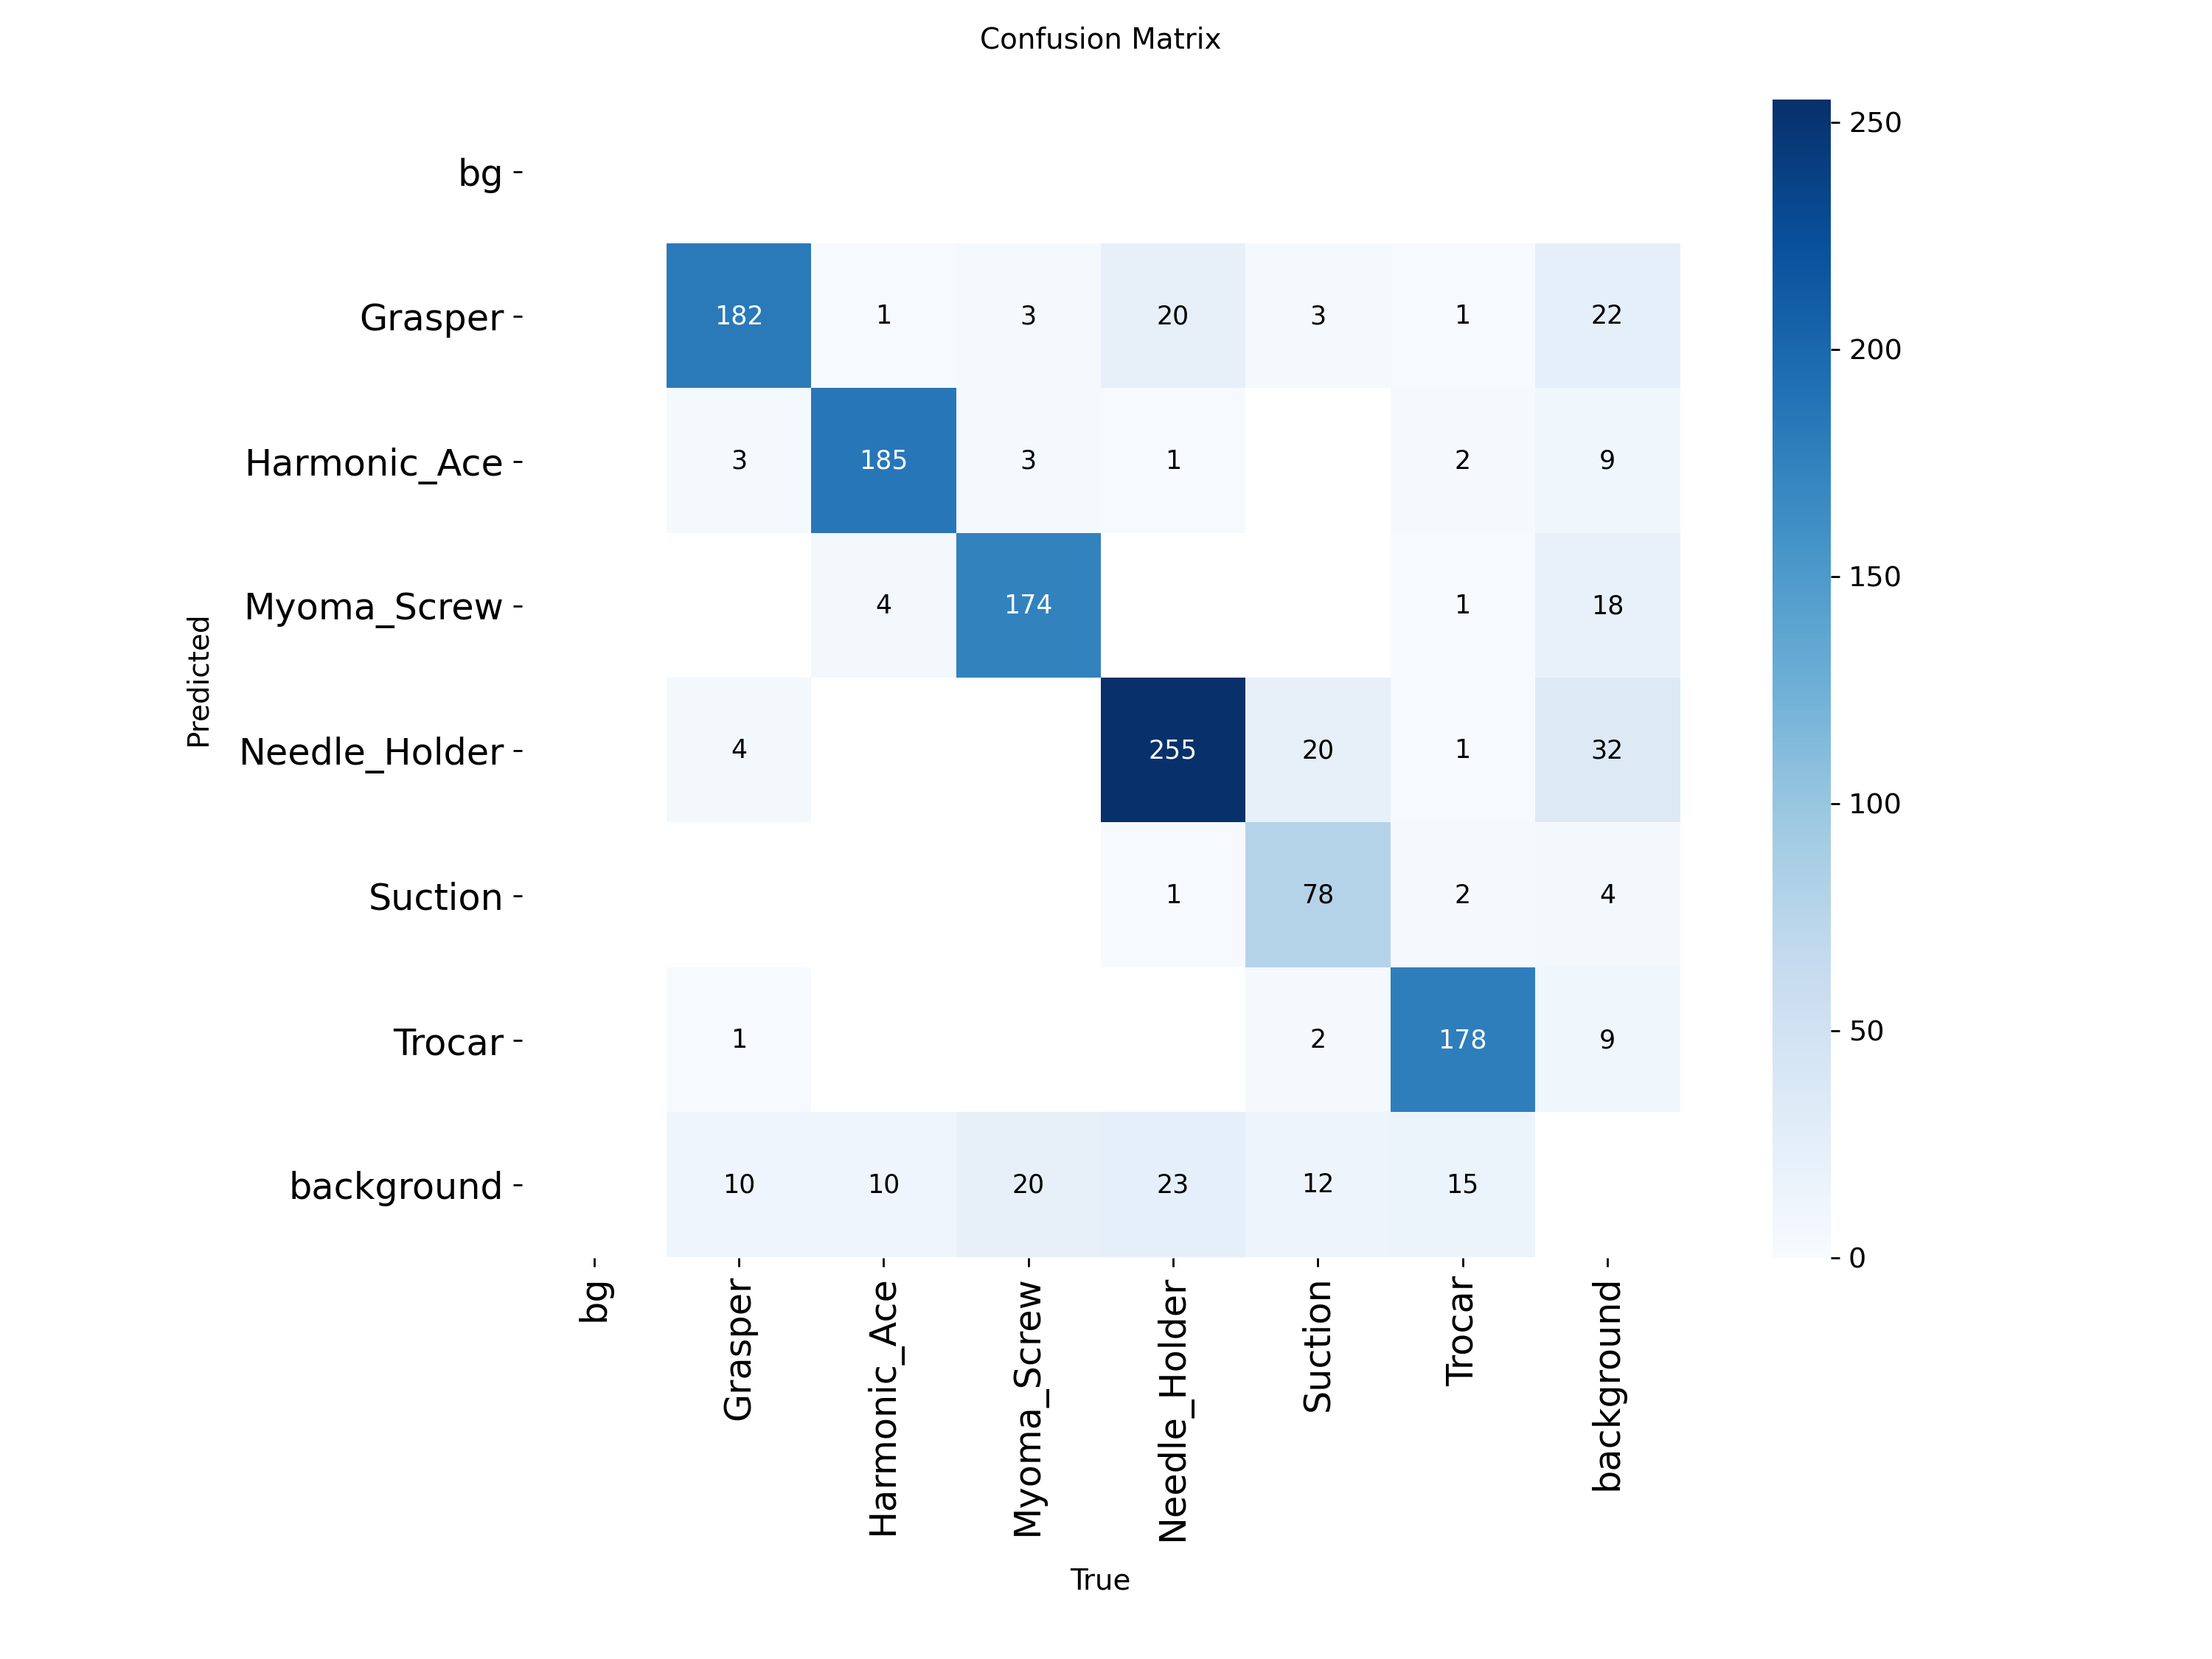

In [50]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'runs/segment/train2/confusion_matrix.png', width=600)

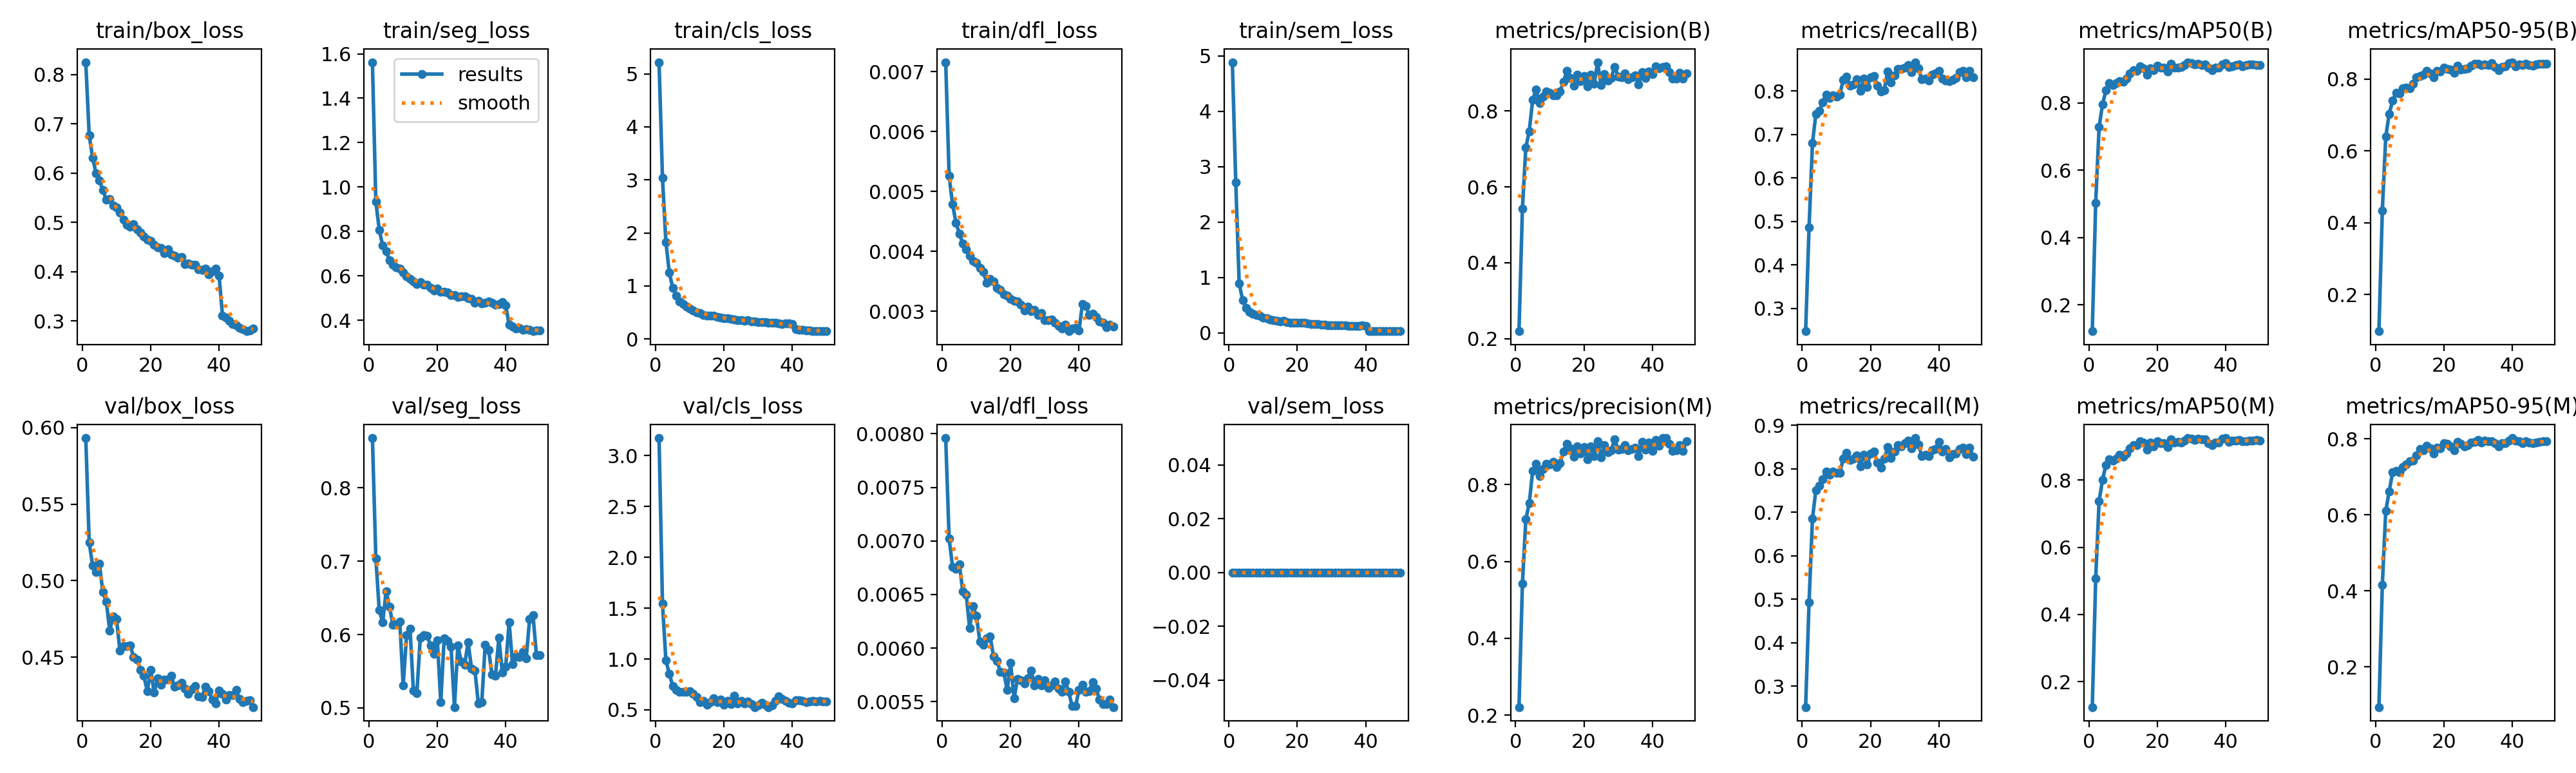

In [52]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'runs/segment/train2/results.png', width=600)

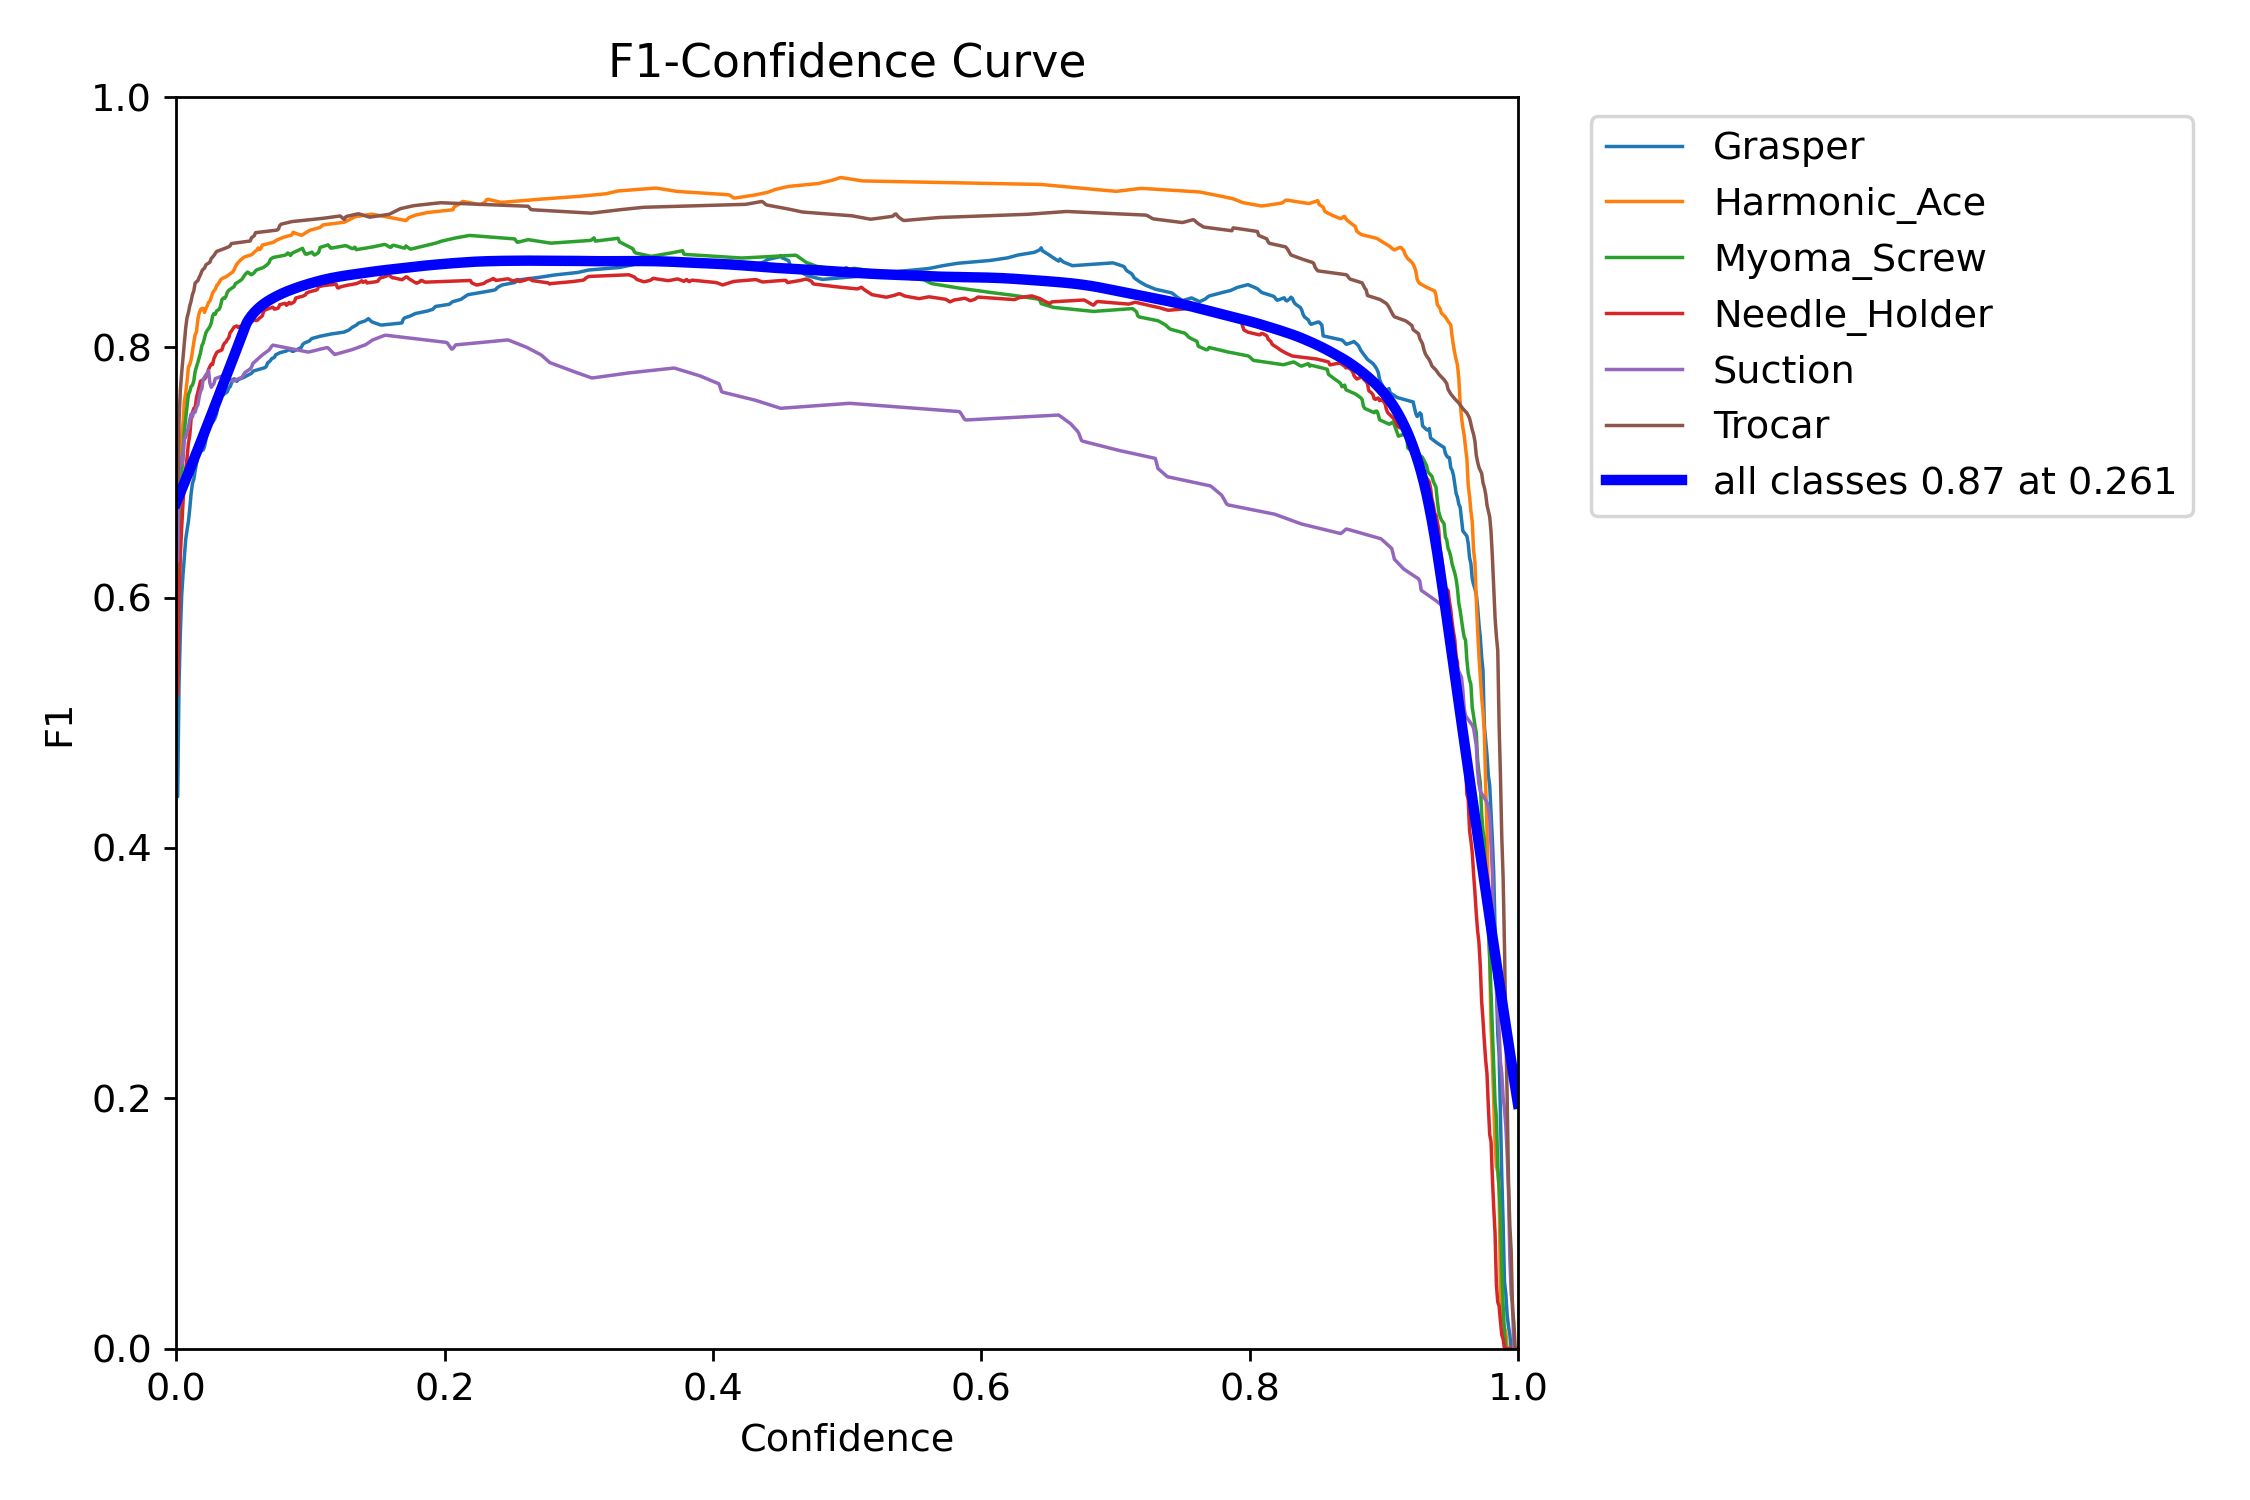

In [53]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'runs/segment/train2/MaskF1_curve.png', width=600)

In [8]:
model = YOLO("runs/segment/train2/weights/best.pt")
model(source="/content/gdrive/MyDrive/yolov11/datasets/surgical_instruments/images/valid", conf=0.3, save=True)


image 1/841 /content/gdrive/MyDrive/yolov11/datasets/surgical_instruments/images/valid/Laparoscopic-Fundoplication-12960_jpg.rf.120a8845031355c28f235911e96b4dec.jpg: 384x640 1 Grasper, 148.8ms
image 2/841 /content/gdrive/MyDrive/yolov11/datasets/surgical_instruments/images/valid/Laparoscopic-Fundoplication-13860_jpg.rf.e1857b5cac4dcecd1969e66a9a0a6986.jpg: 384x640 2 Graspers, 34.7ms
image 3/841 /content/gdrive/MyDrive/yolov11/datasets/surgical_instruments/images/valid/Laparoscopic-Fundoplication-17100_jpg.rf.18c931f970872a53ef2af048e73f3d79.jpg: 384x640 1 Grasper, 34.7ms
image 4/841 /content/gdrive/MyDrive/yolov11/datasets/surgical_instruments/images/valid/Laparoscopic-Fundoplication-18360_jpg.rf.6a71888bc665ad725fe2e40faae8bda5.jpg: 384x640 1 Grasper, 34.7ms
image 5/841 /content/gdrive/MyDrive/yolov11/datasets/surgical_instruments/images/valid/Laparoscopic-Fundoplication-19260_jpg.rf.8bec277c9241bb56f60b7abf4c63084f.jpg: 384x640 2 Graspers, 34.7ms
image 6/841 /content/gdrive/MyDrive/

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'bg', 1: 'Grasper', 2: 'Harmonic_Ace', 3: 'Myoma_Screw', 4: 'Needle_Holder', 5: 'Suction', 6: 'Trocar'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0

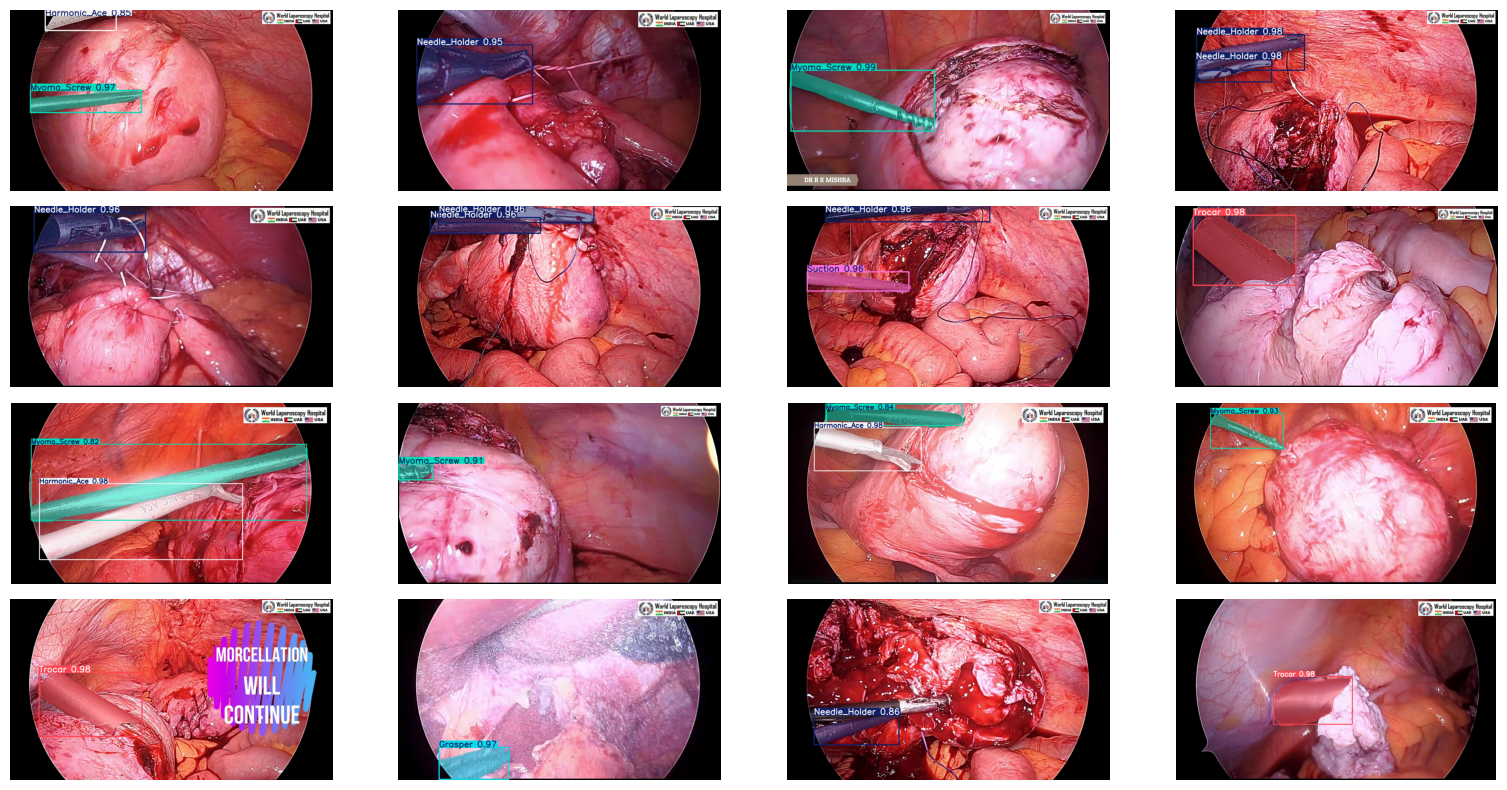

In [13]:
import os, random, cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
results_dir = "runs/segment/predict/"

# visualization layout
N = 16
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(results_dir, f)
            for f in os.listdir(results_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 2 * rows))

for i, image in enumerate(sample_imgs):
    plt.subplot(4, 4, i+1)
    plt.subplot(rows, cols, i + 1)
    image = cv2.imread(image)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
model.export(format='onnx')

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/segment/train2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 300, 38), (1, 32, 160, 160)) (52.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 128ms
Prepared 6 packages in 8.44s
Installed 6 packages in 648ms
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.20.1
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.82

requirements: AutoUpdate success ✅ 9.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 22...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:5353: UserWarning: Exporting aten::index operator of advanced indexing in opset 22 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(


ONNX: slimming with onnxslim 0.1.82...
ONNX: export success ✅ 15.3s, saved as 'runs/segment/train2/weights/best.onnx' (90.0 MB)

Export complete (19.3s)
Results saved to /content/gdrive/.shortcut-targets-by-id/1N1e6L9Tga2bF3c9mKY8K1qjRhbLw7xHn/yolov11/runs/segment/train2/weights
Predict:         yolo predict task=segment model=runs/segment/train2/weights/best.onnx imgsz=640 
Validate:        yolo val task=segment model=runs/segment/train2/weights/best.onnx imgsz=640 data=datasets/sis_final.yaml  
Visualize:       https://netron.app


'runs/segment/train2/weights/best.onnx'

In [40]:
import onnxruntime
import numpy as np
import cv2
import torch

img_path = "/content/gdrive/MyDrive/yolov11/datasets/surgical_instruments/images/valid/Laparoscopic-Surgery-for-Large-Intramural-Fibroid-41-_jpg.rf.2b8540beea87d68d66321b44567672e9.jpg"

img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError(f"Image not found at {img_path}")

img_resized = cv2.resize(img, (640, 640))
img_input = img_resized.astype(np.float32) / 255.0
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Run inference
session = onnxruntime.InferenceSession("runs/segment/train2/weights/best.onnx", providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: img_input})

print("Output:", [o.shape for o in outputs])

out0 = outputs[0]
out1 = outputs[1]

print("out0 shape:", out0.shape)
print("out1 shape:", out1.shape)

# inspect ONE prediction row
row = out0[0, 0]
print("one row length:", row.shape[0])
print("first 10 values:", row[:10])
print("last 40 values:", row[-40:])

Output: [(1, 300, 38), (1, 32, 160, 160)]
out0 shape: (1, 300, 38)
out1 shape: (1, 32, 160, 160)
one row length: 38
first 10 values: [     40.272      99.307       349.5      328.69     0.97364           2    0.080029     -3.2569     0.33077    -0.33603]
last 40 values: [     40.272      99.307       349.5      328.69     0.97364           2    0.080029     -3.2569     0.33077    -0.33603      2.3247       3.367     -3.5038      1.7016     0.27326     0.18302     -1.7743      2.3422     0.62973     0.18232     -2.6817      -3.709    -0.34295     -4.0497       1.707      1.2149
     -2.7992     -2.7892     -2.0871   -0.063994     0.20806    -0.29463     -4.0036      1.5627      1.1987      0.9748      2.0584     -1.0742]


In [43]:
class_names = ['bg', 'Grasper', 'Harmonic_Ace', 'Myoma_Screw', 'Needle_Holder', 'Suction', 'Trocar']

import math
import time

# Create a list of colors for each class where each color is a tuple of 3 integer values
rng = np.random.default_rng(3)
colors = rng.uniform(0, 255, size=(len(class_names), 3))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def draw_detections(image, boxes, scores, class_ids, mask_alpha=0.3, mask_maps=None):
    img_height, img_width = image.shape[:2]
    size = min([img_height, img_width]) * 0.0015
    text_thickness = int(min([img_height, img_width]) * 0.003)

    mask_img = draw_masks(image, boxes, class_ids, mask_alpha, mask_maps)

    # Draw bounding boxes and labels of detections
    for box, score, class_id in zip(boxes, scores, class_ids):
        color = colors[class_id]

        x1, y1, x2, y2 = box.astype(int)

        # Draw rectangle
        cv2.rectangle(mask_img, (x1, y1), (x2, y2), color, 2)

        label = class_names[class_id]
        caption = f'{label} {int(score * 100)}%'
        (tw, th), _ = cv2.getTextSize(text=caption, fontFace=cv2.FONT_HERSHEY_SIMPLEX,
                                      fontScale=size, thickness=text_thickness)
        th = int(th * 1.2)

        cv2.rectangle(mask_img, (x1, y1),
                      (x1 + tw, y1 - th), color, -1)

        cv2.putText(mask_img, caption, (x1, y1),
                    cv2.FONT_HERSHEY_SIMPLEX, size, (255, 255, 255), text_thickness, cv2.LINE_AA)

    return mask_img

def draw_masks(image, boxes, class_ids, mask_alpha=0.3, mask_maps=None):
    mask_img = image.copy()

    # Draw bounding boxes and labels of detections
    for i in range(len(mask_maps)):
        box = boxes[i]
        class_id = class_ids[i]

        color = colors[class_id]

        x1, y1, x2, y2 = box.astype(int)

        # Draw fill mask image
        if mask_maps is None:
            cv2.rectangle(mask_img, (x1, y1), (x2, y2), color, -1)
        else:
            crop_mask = mask_maps[i][y1:y2, x1:x2, np.newaxis]
            crop_mask_img = mask_img[y1:y2, x1:x2]
            crop_mask_img = crop_mask_img * (1 - crop_mask) + crop_mask * color
            mask_img[y1:y2, x1:x2] = crop_mask_img

    return cv2.addWeighted(mask_img, mask_alpha, image, 1 - mask_alpha, 0)

class YOLOSeg:

    def __init__(self, path, conf_thres=0.7, num_masks=32):
        self.conf_threshold = conf_thres
        self.num_masks = num_masks

        # Initialize model
        self.initialize_model(path)

    def __call__(self, image):
        return self.segment_objects(image)

    def initialize_model(self, path):
        self.session = onnxruntime.InferenceSession(path,
                                                    providers=['CUDAExecutionProvider',
                                                               'CPUExecutionProvider'])
        # Get model info
        self.get_input_details()
        self.get_output_details()

    def segment_objects(self, image):
        input_tensor = self.prepare_input(image)

        # Perform inference on the image
        outputs = self.inference(input_tensor)

        self.boxes, self.scores, self.class_ids, mask_pred = self.process_box_output(outputs[0])
        self.mask_maps = self.process_mask_output(mask_pred, outputs[1])

        return self.boxes, self.scores, self.class_ids, self.mask_maps

    def prepare_input(self, image):
        self.img_height, self.img_width = image.shape[:2]

        input_img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize input image
        input_img = cv2.resize(input_img, (self.input_width, self.input_height))

        # Scale input pixel values to 0 to 1
        input_img = input_img / 255.0
        input_img = input_img.transpose(2, 0, 1)
        input_tensor = input_img[np.newaxis, :, :, :].astype(np.float32)

        return input_tensor

    def inference(self, input_tensor):
        start = time.perf_counter()
        outputs = self.session.run(self.output_names, {self.input_names[0]: input_tensor})

        # print(f"Inference time: {(time.perf_counter() - start)*1000:.2f} ms")
        return outputs

    def process_box_output(self, box_output):
        preds = np.squeeze(box_output)  # (300, 38)

        boxes = preds[:, 0:4]           # xyxy already
        scores = preds[:, 4]            # confidence
        class_ids = preds[:, 5].astype(int)
        mask_preds = preds[:, 6:]       # 32 mask coeffs

        keep = scores > self.conf_threshold
        if not np.any(keep):
            return [], [], [], np.array([])

        boxes = boxes[keep]
        scores = scores[keep]
        class_ids = class_ids[keep]
        mask_preds = mask_preds[keep]

        # Rescale boxes from input size to original image size
        boxes[:, [0, 2]] *= self.img_width / self.input_width
        boxes[:, [1, 3]] *= self.img_height / self.input_height

        return boxes, scores, class_ids, mask_preds

    def process_mask_output(self, mask_coeffs, proto):

        if mask_coeffs.shape[0] == 0:
            return []

        proto = np.squeeze(proto)  # (32, mh, mw)
        mh, mw = proto.shape[1:]

        # (N, mh, mw)
        masks = sigmoid(mask_coeffs @ proto.reshape(32, -1))
        masks = masks.reshape(-1, mh, mw)

        valid_masks = []

        for i, box in enumerate(self.boxes):
            x1, y1, x2, y2 = box.astype(int)

            if x2 <= x1 or y2 <= y1:
                continue

            # map box to proto space
            px1 = int(x1 / self.img_width * mw)
            px2 = int(x2 / self.img_width * mw)
            py1 = int(y1 / self.img_height * mh)
            py2 = int(y2 / self.img_height * mh)

            px1 = np.clip(px1, 0, mw)
            px2 = np.clip(px2, 0, mw)
            py1 = np.clip(py1, 0, mh)
            py2 = np.clip(py2, 0, mh)

            if px2 <= px1 or py2 <= py1:
                continue

            crop = masks[i, py1:py2, px1:px2]
            crop = cv2.resize(crop, (x2 - x1, y2 - y1))
            crop = (crop > 0.5).astype(np.uint8)

            full = np.zeros((self.img_height, self.img_width), dtype=np.uint8)
            full[y1:y2, x1:x2] = crop

            valid_masks.append(full)

        return np.array(valid_masks)

    def draw_detections(self, image, draw_scores=True, mask_alpha=0.4):
        return draw_detections(image, self.boxes, self.scores,
                               self.class_ids, mask_alpha)

    def draw_masks(self, image, draw_scores=True, mask_alpha=0.8):
        return draw_detections(image, self.boxes, self.scores,
                               self.class_ids, mask_alpha, mask_maps=self.mask_maps)

    def get_input_details(self):
        model_inputs = self.session.get_inputs()
        self.input_names = [model_inputs[i].name for i in range(len(model_inputs))]

        self.input_shape = model_inputs[0].shape
        self.input_height = self.input_shape[2]
        self.input_width = self.input_shape[3]

    def get_output_details(self):
        model_outputs = self.session.get_outputs()
        self.output_names = [model_outputs[i].name for i in range(len(model_outputs))]

    @staticmethod
    def rescale_boxes(boxes, input_shape, image_shape):
        # Rescale boxes to original image dimensions
        input_shape = np.array([input_shape[1], input_shape[0], input_shape[1], input_shape[0]])
        boxes = np.divide(boxes, input_shape, dtype=np.float32)
        boxes *= np.array([image_shape[1], image_shape[0], image_shape[1], image_shape[0]])

        return boxes

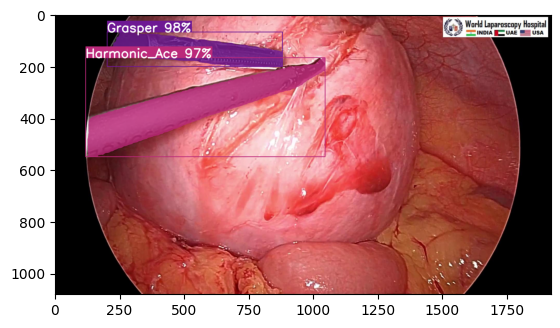

In [47]:
img_path = "/content/gdrive/MyDrive/yolov11/datasets/surgical_instruments/images/valid/Laparoscopic-Surgery-for-Large-Intramural-Fibroid-41-_jpg.rf.2b8540beea87d68d66321b44567672e9.jpg"

img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError(f"Image not found at {img_path}")

# Initialize YOLOv26 Instance Segmentator
yoloseg = YOLOSeg("runs/segment/train2/weights/best.onnx", conf_thres=0.3)

# Detect Objects
yoloseg(img)

# Draw detections
combined_img = yoloseg.draw_masks(img)

import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB))

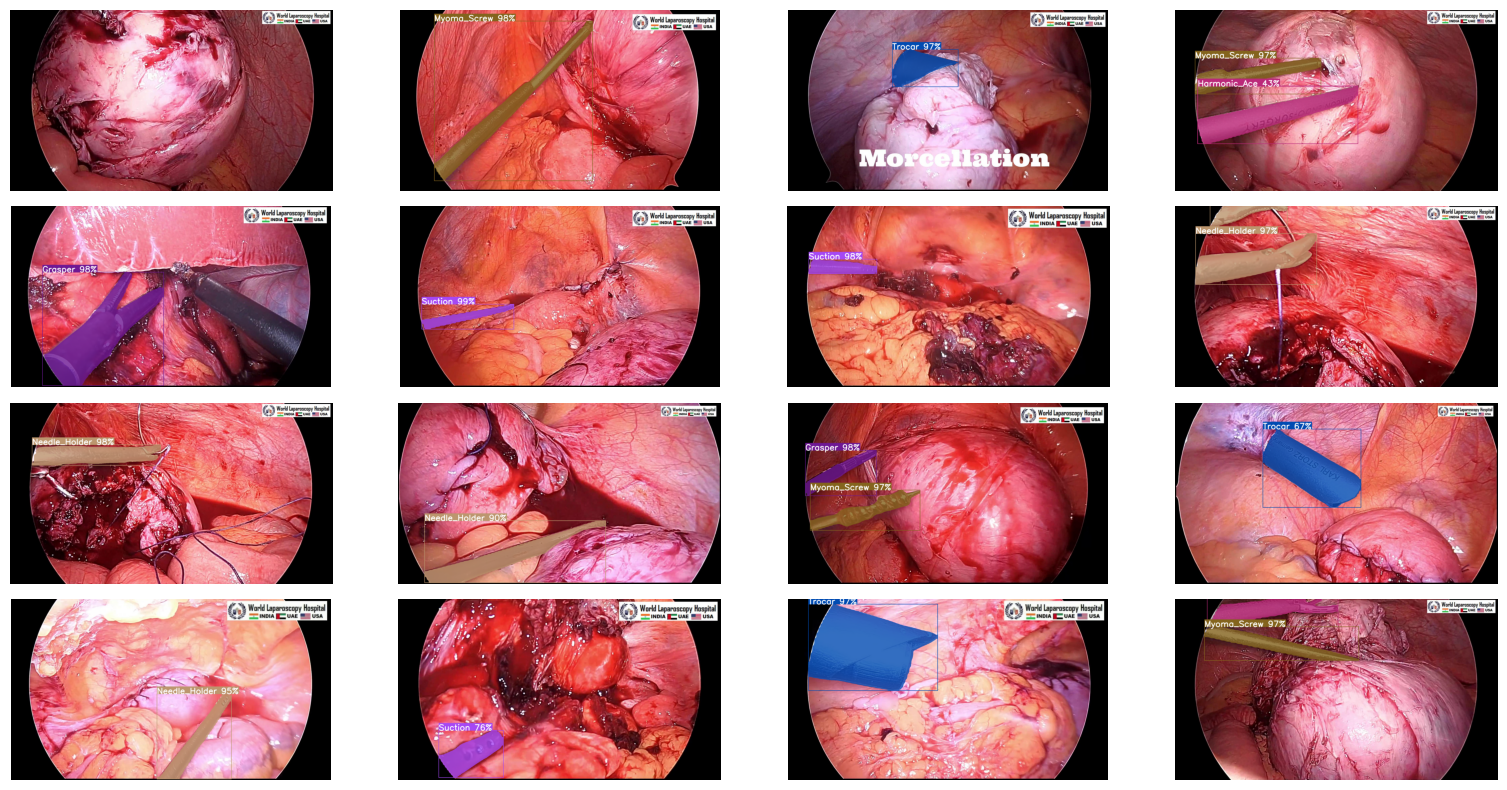

In [48]:
import os, random, cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
results_dir = "/content/gdrive/MyDrive/yolov11/datasets/surgical_instruments/images/valid/"

# Initialize YOLOv26 Instance Segmentator
yoloseg = YOLOSeg("runs/segment/train2/weights/best.onnx", conf_thres=0.3)

# visualization layout
N = 16
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(results_dir, f)
            for f in os.listdir(results_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 2 * rows))

for i, image in enumerate(sample_imgs):
    plt.subplot(4, 4, i+1)
    plt.subplot(rows, cols, i + 1)
    image = cv2.imread(image)

    # Detect Objects
    yoloseg(image)
    # Draw detections
    combined_img = yoloseg.draw_masks(image)
    combined_img = cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB)
    plt.imshow(combined_img)
    plt.axis("off")

plt.tight_layout()
plt.show()